# 04. Simulaciones de sensibilidad

Veo cómo cambian los resultados al mover los parámetros clave de la estrategia, uno a uno:

- Umbral de EV (edge mínimo para apostar): de 2% a 10%.
- Fracción de Kelly: de 5% a 50%.
- Ventana de entrenamiento: expanding y sliding 3/4/5/6/7/9.
- Estrategia de calibración (Experimento 4).

Cada configuración usa el mismo walk-forward con FIRST_TEST=2012 para que sea comparable con el backtest principal del notebook 03.

In [1]:
def build_elo(df, k=30, ha=100, start=1500):
    ratings = {}
    h_elos, a_elos = [], []
    for _, row in df.iterrows():
        h, a, ftr = row['HomeTeam'], row['AwayTeam'], row['FTR']
        rh = ratings.get(h, start); ra = ratings.get(a, start)
        h_elos.append(rh); a_elos.append(ra)
        e_h = 1.0 / (1.0 + 10**((ra - (rh + ha)) / 400.0))
        s_h, s_a = (1,0) if ftr=='H' else ((0.5,0.5) if ftr=='D' else (0,1))
        ratings[h] = rh + k*(s_h - e_h)
        ratings[a] = ra + k*(s_a - (1 - e_h))
    return h_elos, a_elos

import pandas as pd
import numpy as np
import warnings, itertools
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DATA_PATH = '../data/df_final_clean.csv'
FEATURES  = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5','Home_H2H_L3','Away_H2H_L3',
]
# Visitante excluido: sin edge real (ROI -17.55% historico)
ODDS_FILTER = [('1',1.40,1.70),('1',2.00,2.50)]
import json
with open('../results/best_params.json') as _f:
    _bp = json.load(_f)
XGB_PARAMS = {**_bp, 'objective':'multi:softprob', 'num_class':3, 'eval_metric':'mlogloss',
              'random_state':42, 'verbosity':0, 'n_jobs':-1}
# FIRST_TEST=2012 — igual que 03_Backtest para resultados comparables
FIRST_TEST  = 2012
INIT_BK     = 1000.0
FLAT_STAKE  = 10.0
# KILL_THR rebajado a 0.08: con sobreconfianza sistematica de 8-12 pp el 0.12 nunca se activaba
KILL_MIN    = 15
KILL_THR    = 0.08

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['FTR'].isin(['H','D','A'])].dropna(subset=['Season']).copy()
df['Season'] = df['Season'].astype(int)
df = df.sort_values('Date').reset_index(drop=True)
df['Home_Elo_Calc'], df['Away_Elo_Calc'] = build_elo(df)
df['Elo_Diff'] = df['Home_Elo_Calc'] - df['Away_Elo_Calc']
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df = df.dropna(subset=FEATURES+['Target','B365H','B365D','B365A'])
all_seasons  = sorted(df['Season'].unique())
test_seasons = [s for s in all_seasons if s >= FIRST_TEST]
print(f'Dataset listo: {len(df)} partidos | Test: {test_seasons}')
print(f'FIRST_TEST={FIRST_TEST} — igual que 03_Backtest (13 temporadas)')

Dataset listo: 5700 partidos | Test: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
FIRST_TEST=2012 — igual que 03_Backtest (13 temporadas)


In [2]:
def run_backtest(df, all_seasons, test_seasons, train_window, min_ev,
                  kelly_frac, kelly_max=0.05):
    """
    Ejecuta el backtest walk-forward con los parametros dados.
    Devuelve dict con: flat_roi, kelly_roi, n_bets, pos_seasons, total_seasons,
    max_dd (flat bankroll), max_dd_kelly (kelly bankroll).
    """
    all_bets, season_flat_rois = [], []

    for test_s in test_seasons:
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior if train_window is None else prior[-train_window:]
        if not tr_s: continue

        tr = df['Season'].isin(tr_s)
        te = df['Season'] == test_s
        X_tr = df.loc[tr, FEATURES].values
        y_tr = df.loc[tr,'Target'].values
        X_te = df.loc[te, FEATURES].values
        df_te = df[te].reset_index(drop=True)

        if len(X_tr) < 50 or len(X_te) == 0: continue

        model = CalibratedClassifierCV(XGBClassifier(**XGB_PARAMS),
                                        method='isotonic', cv=TimeSeriesSplit(n_splits=3))
        model.fit(X_tr, y_tr)
        proba   = model.predict_proba(X_te)
        classes = list(model.classes_)
        p_H = proba[:, classes.index(2)]
        p_D = proba[:, classes.index(1)]
        p_A = proba[:, classes.index(0)]

        bets = []
        killed = False
        for i, row in df_te.iterrows():
            if killed:
                break
            oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= min_ev: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
                ks = max(0.0, min((p*odds-1)/(odds-1)*kelly_frac, kelly_max)) * INIT_BK
                bets.append({
                    'Won': won, 'Odds': odds, 'P_Model': p,
                    'Flat_P': FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                    'Kelly_P': ks*(odds-1) if won else -ks,
                    'Kelly_S': ks,
                })
            # Kill switch correcto: obs vs P_Model predicho (no vs umbral fijo)
            if len(bets) >= KILL_MIN:
                obs = sum(1 for b in bets if b['Won']) / len(bets)
                exp = sum(b['P_Model'] for b in bets) / len(bets)
                if obs < exp - KILL_THR:
                    killed = True

        if bets:
            b = pd.DataFrame(bets)
            fr = b['Flat_P'].sum() / (len(b) * FLAT_STAKE)
            season_flat_rois.append(fr)
            all_bets.extend(bets)

    if not all_bets:
        return {'flat_roi': 0, 'kelly_roi': 0, 'n_bets': 0,
                'pos_seasons': 0, 'total_seasons': 0, 'max_dd': 0, 'max_dd_kelly': 0}

    ab = pd.DataFrame(all_bets)
    flat_roi  = ab['Flat_P'].sum() / (len(ab) * FLAT_STAKE)
    ks_sum    = ab['Kelly_S'].sum()
    kelly_roi = ab['Kelly_P'].sum() / ks_sum if ks_sum > 0 else 0

    # Drawdown sobre flat bankroll
    bk_flat   = INIT_BK + ab['Flat_P'].cumsum()
    peak_flat = np.maximum.accumulate(bk_flat)
    max_dd    = ((bk_flat - peak_flat) / peak_flat).min()

    # Drawdown sobre Kelly bankroll (varia con kelly_frac)
    bk_kelly  = INIT_BK + ab['Kelly_P'].cumsum()
    peak_kelly = np.maximum.accumulate(bk_kelly)
    max_dd_kelly = ((bk_kelly - peak_kelly) / peak_kelly).min()

    return {'flat_roi': flat_roi, 'kelly_roi': kelly_roi,
            'n_bets': len(ab),
            'pos_seasons': sum(r > 0 for r in season_flat_rois),
            'total_seasons': len(season_flat_rois),
            'max_dd': max_dd,
            'max_dd_kelly': max_dd_kelly}

print('Funcion run_backtest definida (kill switch corregido, drawdown Kelly separado).')

Funcion run_backtest definida (kill switch corregido, drawdown Kelly separado).


## Experimento 1 — Umbral de EV

In [3]:
ev_grid = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10]
ev_results = []

for ev in ev_grid:
    r = run_backtest(df, all_seasons, test_seasons,
                     train_window=5, min_ev=ev, kelly_frac=0.25)
    ev_results.append({'EV_min': ev, **r})
    print(f'  EV>{ev:.0%}  bets={r["n_bets"]:4}  '
          f'flat={r["flat_roi"]:+.2%}  kelly={r["kelly_roi"]:+.2%}  '
          f'pos={r["pos_seasons"]}/{r["total_seasons"]}  dd={r["max_dd"]:.1%}')

df_ev = pd.DataFrame(ev_results)


  EV>2%  bets= 407  flat=-3.18%  kelly=-3.40%  pos=4/13  dd=-28.1%
  EV>3%  bets= 386  flat=-4.00%  kelly=-3.75%  pos=4/13  dd=-30.2%
  EV>4%  bets= 352  flat=-1.34%  kelly=-3.01%  pos=4/13  dd=-27.6%
  EV>5%  bets= 344  flat=+2.59%  kelly=-0.49%  pos=5/13  dd=-22.8%
  EV>6%  bets= 327  flat=+4.09%  kelly=+0.98%  pos=6/13  dd=-18.0%
  EV>7%  bets= 309  flat=+2.63%  kelly=+0.53%  pos=6/13  dd=-18.1%
  EV>8%  bets= 292  flat=+1.10%  kelly=+0.60%  pos=6/13  dd=-17.0%
  EV>10%  bets= 270  flat=-0.63%  kelly=-1.13%  pos=5/13  dd=-14.7%


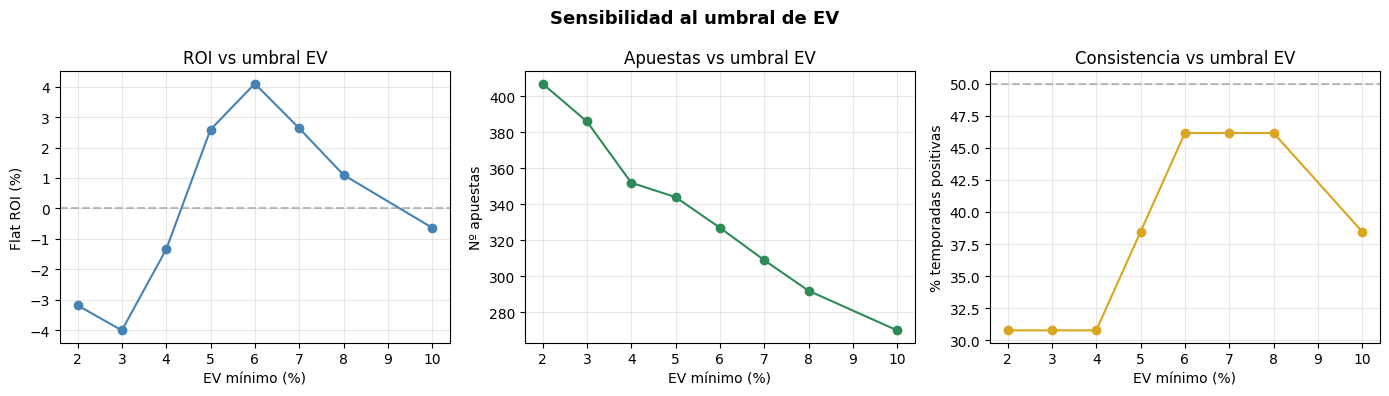

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(df_ev['EV_min']*100, df_ev['flat_roi']*100, 'o-', color='steelblue')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('EV mínimo (%)'); axes[0].set_ylabel('Flat ROI (%)'); axes[0].set_title('ROI vs umbral EV')
axes[0].grid(alpha=0.3)

axes[1].plot(df_ev['EV_min']*100, df_ev['n_bets'], 'o-', color='seagreen')
axes[1].set_xlabel('EV mínimo (%)'); axes[1].set_ylabel('Nº apuestas'); axes[1].set_title('Apuestas vs umbral EV')
axes[1].grid(alpha=0.3)

axes[2].plot(df_ev['EV_min']*100, df_ev['pos_seasons']/df_ev['total_seasons']*100, 'o-', color='goldenrod')
axes[2].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('EV mínimo (%)'); axes[2].set_ylabel('% temporadas positivas')
axes[2].set_title('Consistencia vs umbral EV'); axes[2].grid(alpha=0.3)

plt.suptitle('Sensibilidad al umbral de EV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/sim_ev_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


## Experimento 2 — Fracción de Kelly

In [5]:
kelly_grid = [0.05, 0.10, 0.15, 0.20, 0.25, 0.33, 0.50]
kelly_results = []

for kf in kelly_grid:
    r = run_backtest(df, all_seasons, test_seasons,
                     train_window=5, min_ev=0.05, kelly_frac=kf)
    kelly_results.append({'Kelly_frac': kf, **r})
    # Mostrar drawdown Kelly (varia con fraccion) y flat (constante, para referencia)
    print(f'  Kelly={kf:.0%}  kelly_roi={r["kelly_roi"]:+.2%}  '
          f'pos={r["pos_seasons"]}/{r["total_seasons"]}  '
          f'dd_flat={r["max_dd"]:.1%}  dd_kelly={r["max_dd_kelly"]:.1%}')

df_kelly = pd.DataFrame(kelly_results)

  Kelly=5%  kelly_roi=-2.00%  pos=5/13  dd_flat=-22.8%  dd_kelly=-25.8%
  Kelly=10%  kelly_roi=-1.71%  pos=5/13  dd_flat=-22.8%  dd_kelly=-43.5%
  Kelly=15%  kelly_roi=-1.15%  pos=5/13  dd_flat=-22.8%  dd_kelly=-52.2%
  Kelly=20%  kelly_roi=-0.65%  pos=5/13  dd_flat=-22.8%  dd_kelly=-56.4%
  Kelly=25%  kelly_roi=-0.49%  pos=5/13  dd_flat=-22.8%  dd_kelly=-60.5%
  Kelly=33%  kelly_roi=+0.25%  pos=5/13  dd_flat=-22.8%  dd_kelly=-62.6%
  Kelly=50%  kelly_roi=+1.47%  pos=5/13  dd_flat=-22.8%  dd_kelly=-61.1%


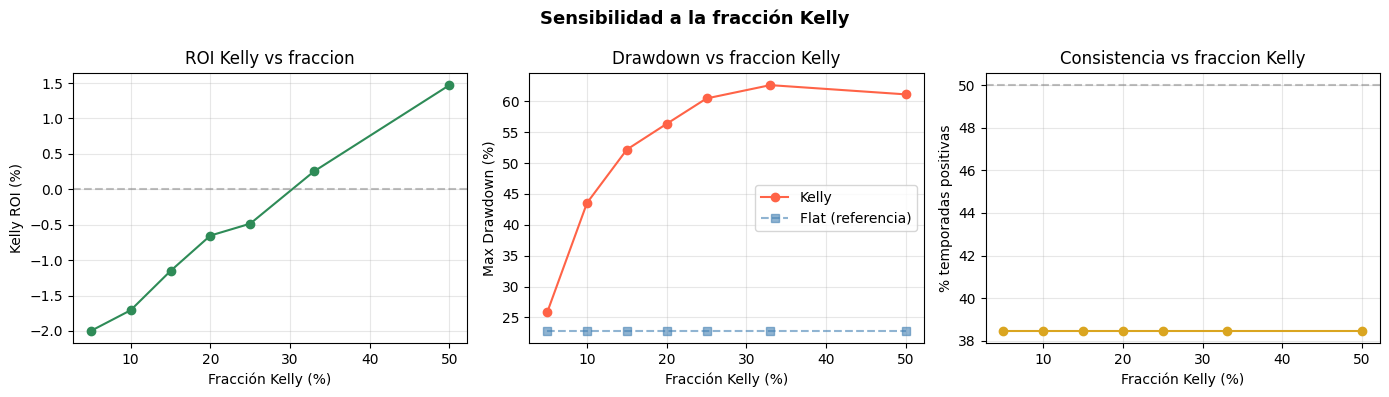

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(df_kelly['Kelly_frac']*100, df_kelly['kelly_roi']*100, 'o-', color='seagreen')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Fracción Kelly (%)'); axes[0].set_ylabel('Kelly ROI (%)'); axes[0].set_title('ROI Kelly vs fraccion')
axes[0].grid(alpha=0.3)

# Drawdown Kelly (varia con fraccion) — antes estaba usando flat, que era constante
axes[1].plot(df_kelly['Kelly_frac']*100, -df_kelly['max_dd_kelly']*100, 'o-', color='tomato', label='Kelly')
axes[1].plot(df_kelly['Kelly_frac']*100, -df_kelly['max_dd']*100, 's--', color='steelblue', alpha=0.6, label='Flat (referencia)')
axes[1].set_xlabel('Fracción Kelly (%)'); axes[1].set_ylabel('Max Drawdown (%)'); axes[1].set_title('Drawdown vs fraccion Kelly')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(df_kelly['Kelly_frac']*100, df_kelly['pos_seasons']/df_kelly['total_seasons']*100, 'o-', color='goldenrod')
axes[2].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Fracción Kelly (%)'); axes[2].set_ylabel('% temporadas positivas'); axes[2].set_title('Consistencia vs fraccion Kelly')
axes[2].grid(alpha=0.3)

plt.suptitle('Sensibilidad a la fracción Kelly', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/sim_kelly_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

## Experimento 3 — Ventana de entrenamiento

In [7]:
window_grid = [None, 3, 4, 5, 6, 7, 9]  # None = expanding
window_results = []

for w in window_grid:
    r = run_backtest(df, all_seasons, test_seasons,
                     train_window=w, min_ev=0.05, kelly_frac=0.25)
    label = 'expanding' if w is None else f'sliding {w}'
    window_results.append({'Window': label, 'W_val': 99 if w is None else w, **r})
    print(f'  {label:12}  flat={r["flat_roi"]:+.2%}  bets={r["n_bets"]:4}  '
          f'pos={r["pos_seasons"]}/{r["total_seasons"]}')

df_window = pd.DataFrame(window_results)


  expanding     flat=+0.77%  bets= 356  pos=4/13
  sliding 3     flat=+4.88%  bets= 355  pos=6/13
  sliding 4     flat=-1.82%  bets= 325  pos=3/13
  sliding 5     flat=+2.59%  bets= 344  pos=5/13
  sliding 6     flat=-2.44%  bets= 332  pos=4/13
  sliding 7     flat=-1.10%  bets= 341  pos=4/13
  sliding 9     flat=-1.01%  bets= 343  pos=4/13


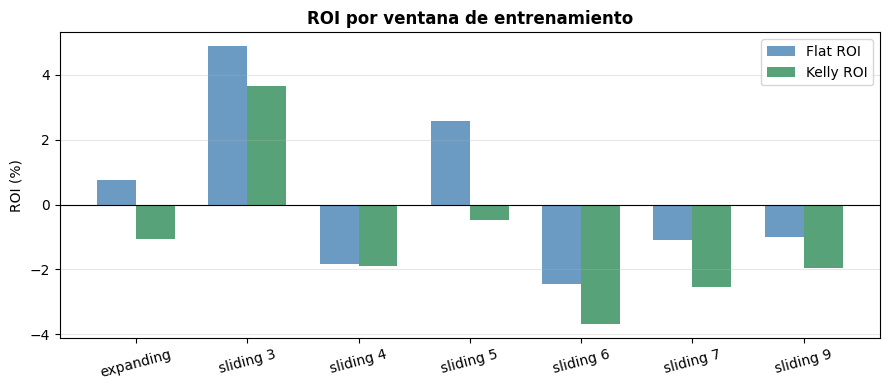

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
labels  = df_window['Window']
x       = range(len(labels))
width   = 0.35
ax.bar([i - width/2 for i in x], df_window['flat_roi']*100, width, color='steelblue', alpha=0.8, label='Flat ROI')
ax.bar([i + width/2 for i in x], df_window['kelly_roi']*100, width, color='seagreen', alpha=0.8, label='Kelly ROI')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('ROI (%)'); ax.set_title('ROI por ventana de entrenamiento', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/sim_window_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


## Resumen de los tres experimentos

In [9]:
# Tabla resumen de los 3 experimentos
print('=== EXPERIMENTO 1: Umbral EV ===')
print(df_ev[['EV_min','n_bets','flat_roi','kelly_roi','pos_seasons','total_seasons','max_dd']].to_string(index=False))
print()
print('=== EXPERIMENTO 2: Fraccion Kelly ===')
print(df_kelly[['Kelly_frac','kelly_roi','pos_seasons','total_seasons','max_dd']].to_string(index=False))
print()
print('=== EXPERIMENTO 3: Ventana de entrenamiento ===')
print(df_window[['Window','n_bets','flat_roi','kelly_roi','pos_seasons','total_seasons']].to_string(index=False))

# Guardar
df_ev.to_csv('../results/sim_ev_sweep.csv', index=False)
df_kelly.to_csv('../results/sim_kelly_sweep.csv', index=False)
df_window.to_csv('../results/sim_window_sweep.csv', index=False)
print('Resultados guardados en results/')


=== EXPERIMENTO 1: Umbral EV ===
 EV_min  n_bets  flat_roi  kelly_roi  pos_seasons  total_seasons    max_dd
   0.02     407 -0.031769  -0.034049            4             13 -0.281363
   0.03     386 -0.040000  -0.037457            4             13 -0.301505
   0.04     352 -0.013437  -0.030070            4             13 -0.276161
   0.05     344  0.025872  -0.004856            5             13 -0.228101
   0.06     327  0.040948   0.009780            6             13 -0.180226
   0.07     309  0.026311   0.005280            6             13 -0.181437
   0.08     292  0.011027   0.005961            6             13 -0.170271
   0.10     270 -0.006333  -0.011297            5             13 -0.146864

=== EXPERIMENTO 2: Fraccion Kelly ===
 Kelly_frac  kelly_roi  pos_seasons  total_seasons    max_dd
       0.05  -0.019999            5             13 -0.228101
       0.10  -0.017074            5             13 -0.228101
       0.15  -0.011532            5             13 -0.228101
       0.

## Conclusiones de los experimentos 1-3

EV mínimo: 4 de 8 umbrales dan ROI flat positivo. El mejor es **EV>6% (+4.09%, 327 apuestas, 6/13 temporadas positivas)**, seguido de EV>7% (+2.63%, 6/13), EV>5% (+2.59%, config base, 5/13) y EV>8% (+1.10%, 6/13). Los umbrales bajos (2-4%) son negativos y EV>10% se cae a -0.63%: aceptar apuestas con edge marginal hunde el agregado, y exigir demasiado deja una muestra demasiado pequeña. El sweet spot está alrededor de 6-7%.

Fracción de Kelly: con compounding real, la mayoría de fracciones siguen en negativo. La de 50% es la única claramente positiva (+1.47%) pero a costa de un drawdown del -61.1%, inaceptable en cualquier interpretación operativa. La de 33% queda casi neutra (+0.25%, dd -62.6%). Las conservadoras (5-25%) están entre -2.00% y -0.49%. La elección base de 0.25 da -0.49% con drawdown -60.5%. Resumen: el flat ROI es marginal y Kelly no aporta valor en este contexto; las fracciones altas amplifican rachas malas más de lo que mejoran el agregado.

Ventana de entrenamiento: sliding 3 destaca con +4.88% (355 bets, 6/13 temporadas positivas). Sliding 5 (config base) queda en +2.59% (5/13) y expanding casi neutra (+0.77%). Las demás (sliding 4, 6, 7, 9) son negativas. Sliding 3 es la mejor del barrido pero hay que tomarla con pinzas: una ventana ganadora entre siete probadas tiene un componente claro de selección post-hoc. La elección base de sliding 5 no es óptima en yield pero sí más estable: bastante historia para entrenar y suficiente recencia para no arrastrar partidos antiguos.

## Experimento 4 — Estrategia de calibración

En el notebook 05 vi que isotónica con `TimeSeriesSplit(n_splits=3)` deja una ECE moderada (sobreconfianza de 6-9 pp). Sigmoid no mejora; los dos métodos sufren igual cuando la muestra de calibración es pequeña.

Aquí pruebo dos vías alternativas:

1. Expanding window: usar más partidos históricos para la calibración, a ver si más datos ayudan.
2. Temperature scaling: calibración post-hoc con un solo parámetro T aprendido en un split de validación. Más estable que isotonic/sigmoid con poca muestra.

La referencia es el backtest principal (sliding 5 + isotonic + KS, calibración con `TimeSeriesSplit`): Flat ROI +2.59%, 5/13 temporadas positivas, 344 apuestas, ECE 0.0707.

In [10]:
import warnings, time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from scipy.optimize import minimize_scalar

MIN_EV     = 0.05
KELLY_FRAC = 0.25
KELLY_MAX  = 0.05

def ece(p_pred, y_true, n_bins=10):
    bins, val = np.linspace(0,1,n_bins+1), 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (p_pred >= lo) & (p_pred < hi)
        if m.sum() == 0: continue
        val += m.mean() * abs(p_pred[m].mean() - y_true[m].mean())
    return val

def kelly_stake(p, odds):
    return max(0.0, min((p*odds-1)/(odds-1)*KELLY_FRAC, KELLY_MAX)) * INIT_BK

def apply_temperature(probs, T):
    eps = 1e-7
    logits = np.log(np.clip(probs, eps, 1-eps))
    scaled = logits / T
    exp_s  = np.exp(scaled - scaled.max(axis=1, keepdims=True))
    return exp_s / exp_s.sum(axis=1, keepdims=True)

def find_temperature(probs_cal, y_cal):
    def nll(T):
        p   = apply_temperature(probs_cal, T)
        eps = 1e-7
        return -np.mean(np.log(np.clip(
            p[np.arange(len(y_cal)), y_cal.astype(int)], eps, 1
        )))
    result = minimize_scalar(nll, bounds=(0.5, 10.0), method='bounded')
    return result.x

def run_experiment(train_window, calib_method):
    """
    train_window : None=expanding | int=sliding N temporadas
    calib_method : 'isotonic' | 'temperature'
    """
    all_bets, season_rows = [], []

    for test_s in test_seasons:
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior if train_window is None else prior[-train_window:]
        if not tr_s: continue

        tr, te = df['Season'].isin(tr_s), df['Season'] == test_s
        X_tr = df.loc[tr, FEATURES].values
        y_tr = df.loc[tr, 'Target'].values
        df_te = df[te].reset_index(drop=True)
        if len(X_tr) < 50 or len(df_te) == 0: continue

        if calib_method == 'temperature':
            cut = int(len(X_tr) * 0.8)
            base = XGBClassifier(**XGB_PARAMS)
            base.fit(X_tr[:cut], y_tr[:cut])
            probs_cal = base.predict_proba(X_tr[cut:])
            y_cal     = y_tr[cut:]
            cls_base  = list(base.classes_)
            T = find_temperature(probs_cal, y_cal)
            probs_test_raw = base.predict_proba(df_te[FEATURES].values)
            probs_test = apply_temperature(probs_test_raw, T)
            classes = cls_base
        else:
            model = CalibratedClassifierCV(
                XGBClassifier(**XGB_PARAMS), method=calib_method, cv=TimeSeriesSplit(n_splits=3)
            )
            model.fit(X_tr, y_tr)
            probs_test = model.predict_proba(df_te[FEATURES].values)
            classes    = list(model.classes_)

        p_H = probs_test[:, classes.index(2)]
        p_D = probs_test[:, classes.index(1)]
        p_A = probs_test[:, classes.index(0)]

        bets = []
        killed = False
        for i, row in df_te.iterrows():
            if killed:
                break
            oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= MIN_EV: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
                ks = kelly_stake(p, odds)
                bets.append({
                    'Season': test_s, 'P_Model': p, 'Won': int(won),
                    'Flat_P':   FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                    'Kelly_P':  ks*(odds-1) if won else -ks,
                    'Kelly_S':  ks, 'Flat_S': FLAT_STAKE,
                })
            # Kill switch correcto: obs vs P_Model predicho
            if len(bets) >= KILL_MIN:
                obs = sum(b['Won'] for b in bets) / len(bets)
                exp = sum(b['P_Model'] for b in bets) / len(bets)
                if obs < exp - KILL_THR:
                    killed = True

        if bets:
            b   = pd.DataFrame(bets)
            fr  = b['Flat_P'].sum() / b['Flat_S'].sum()
            ks  = b['Kelly_S'].sum()
            kr  = b['Kelly_P'].sum() / ks if ks > 0 else 0
            ec  = ece(b['P_Model'].values, b['Won'].values.astype(float))
            season_rows.append({
                'Season': int(test_s), 'N_Bets': len(b),
                'Overconf': round(b['P_Model'].mean() - b['Won'].mean(), 4),
                'ECE': round(ec, 4),
                'Flat_ROI': round(fr, 4),
                'Kelly_ROI': round(kr, 4),
                'Flat_PnL': round(b['Flat_P'].sum(), 2),
            })
            all_bets.extend(bets)

    ab  = pd.DataFrame(all_bets)
    res = pd.DataFrame(season_rows)
    return {
        'res':        res,
        'ECE':        round(ece(ab['P_Model'].values, ab['Won'].values.astype(float)), 4),
        'flat_roi':   round(ab['Flat_P'].sum() / ab['Flat_S'].sum(), 4),
        'kelly_roi':  round(ab['Kelly_P'].sum() / ab['Kelly_S'].sum()
                            if ab['Kelly_S'].sum() > 0 else 0, 4),
        'n_bets':     len(ab),
        'pos':        int((res['Flat_ROI'] > 0).sum()),
        'n_seasons':  len(res),
        'final_bk':   round(INIT_BK + ab['Flat_P'].sum(), 0),
    }

configs = [
    ('sliding 5  + isotonic',    5,    'isotonic'),
    ('expanding  + isotonic',    None, 'isotonic'),
    ('sliding 5  + temperature', 5,    'temperature'),
    ('expanding  + temperature', None, 'temperature'),
]

results = {}
for label, window, method in configs:
    t0 = time.time()
    print(f'Ejecutando: {label}...', end=' ')
    results[label] = run_experiment(window, method)
    print(f'{time.time()-t0:.0f}s')

print('Listo.')

Ejecutando: sliding 5  + isotonic... 17s
Ejecutando: expanding  + isotonic... 17s
Ejecutando: sliding 5  + temperature... 6s
Ejecutando: expanding  + temperature... 7s
Listo.


In [11]:
# --- Tabla comparativa ---
print(f'{"Configuracion":<32} {"ECE":>7} {"FlatROI":>9} {"KellyROI":>10} '
      f'{"Bets":>6} {"Pos":>6} {"BK final":>10}')
print('-' * 83)
for label, r in results.items():
    print(f'{label:<32} {r["ECE"]:>7.4f} {r["flat_roi"]*100:>+8.2f}% '
          f'{r["kelly_roi"]*100:>+9.2f}% {r["n_bets"]:>6} '
          f'{r["pos"]:>3}/{r["n_seasons"]} {r["final_bk"]:>10,.0f} EUR')

# Referencia dinamica: leemos los CSVs guardados por 03_Backtest
print()
print('Referencia (03_Backtest, sliding 5 + isotonic + KS, cv=TimeSeriesSplit):')
try:
    _bets_ref = pd.read_csv('../results/backtest_master_bets.csv')
    _seas_ref = pd.read_csv('../results/backtest_master_seasons.csv')
    _n = len(_bets_ref)
    _flat = _bets_ref['Flat_Profit'].sum() / (_n * FLAT_STAKE) if _n else 0.0
    _ks_sum = _bets_ref['Kelly_Stake'].sum() if 'Kelly_Stake' in _bets_ref else 0
    _kelly = _bets_ref['Kelly_Profit'].sum() / _ks_sum if _ks_sum > 0 else 0.0
    _pos = int((_seas_ref['Flat_ROI'] > 0).sum())
    _tot = len(_seas_ref)
    _bk = INIT_BK + _bets_ref['Flat_Profit'].sum()
    print(f'  sliding 5 + isotonic  Flat={_flat*100:+.2f}%  Kelly={_kelly*100:+.2f}%  '
          f'bets={_n}  {_pos}/{_tot}  {_bk:,.0f} EUR')
except FileNotFoundError:
    print('  (CSVs del backtest no encontrados; ejecuta 03_Backtest.ipynb primero)')


Configuracion                        ECE   FlatROI   KellyROI   Bets    Pos   BK final
-----------------------------------------------------------------------------------
sliding 5  + isotonic             0.0707    +2.59%     -0.49%    344   5/13      1,089 EUR
expanding  + isotonic             0.0801    +0.77%     -1.06%    356   4/13      1,027 EUR
sliding 5  + temperature          0.0875    -4.20%     -2.30%    333   3/13        860 EUR
expanding  + temperature          0.0822    -2.41%     -3.48%    364   4/13        912 EUR

Referencia (03_Backtest, sliding 5 + isotonic + KS, cv=TimeSeriesSplit):
  sliding 5 + isotonic  Flat=+2.59%  Kelly=-1.82%  bets=344  5/13  1,089 EUR


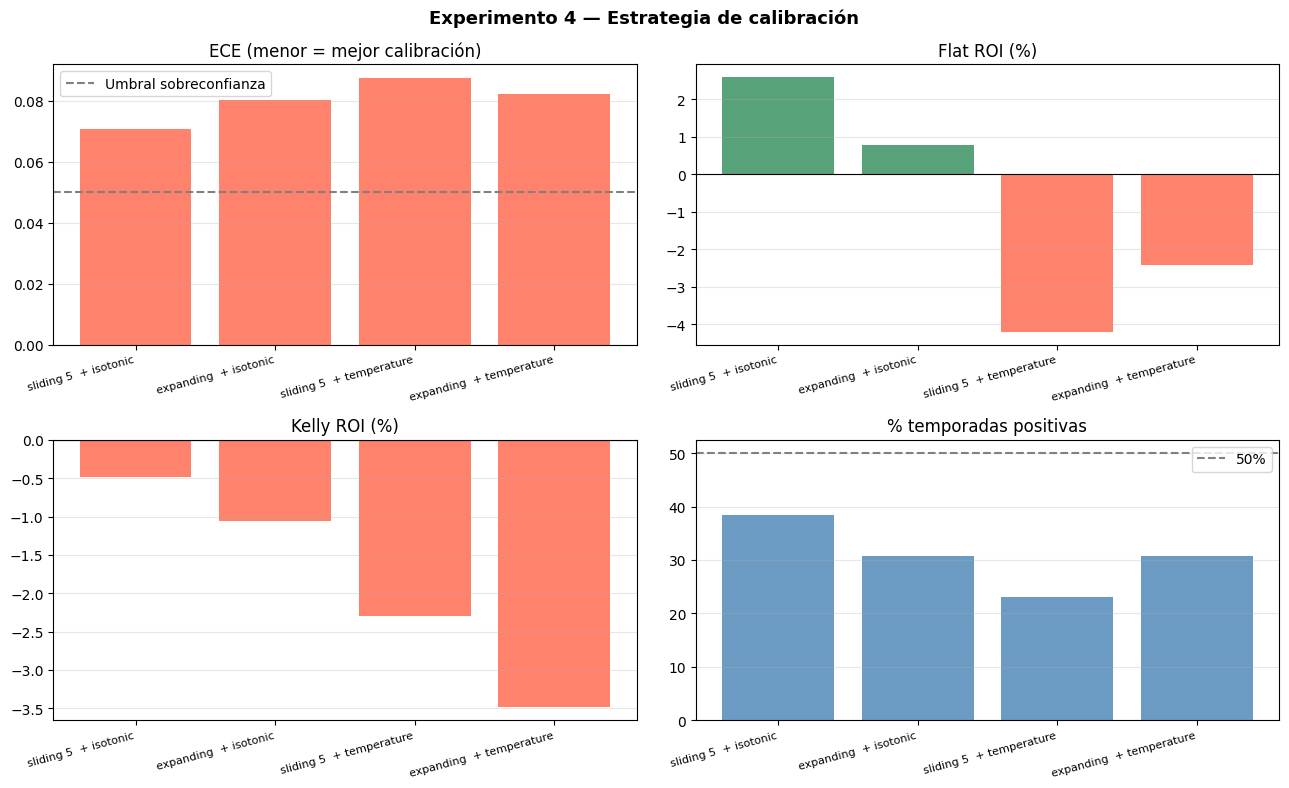


Detalle por temporada — Flat ROI:
 Season  ECE_slid_x  ROI_slid_x  ECE_expa_x  ROI_expa_x  ECE_slid_y  ROI_slid_y  ECE_expa_y  ROI_expa_y
   2012      0.0531      0.1618      0.0531      0.1618      0.0807      0.0607      0.0807      0.0607
   2013      0.0801      0.0247      0.0801      0.0247      0.0568      0.0920      0.0568      0.0920
   2014      0.2041     -0.0327      0.2041     -0.0327      0.2086     -0.1973      0.2086     -0.1973
   2015      0.1723     -0.1613      0.1723     -0.1613      0.2672     -0.3533      0.2672     -0.3533
   2016      0.1573      0.2063      0.2004     -0.0768      0.1254     -0.0869      0.2094     -0.3240
   2017      0.1336      0.1428      0.0425      0.1324      0.1542      0.0649      0.0877      0.2130
   2018      0.4182     -0.1887      0.4951     -0.4787      0.2302     -0.2353      0.4485     -0.6047
   2019      0.4082     -0.5200      0.3133     -0.4167      0.1374     -0.0744      0.1880     -0.2320
   2020      0.1385     -0.03

In [12]:
import matplotlib.pyplot as plt

labels  = list(results.keys())
ece_v   = [results[l]['ECE']        for l in labels]
flat_v  = [results[l]['flat_roi']*100 for l in labels]
kelly_v = [results[l]['kelly_roi']*100 for l in labels]
pos_v   = [results[l]['pos']/results[l]['n_seasons']*100 for l in labels]

x = range(len(labels))
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

colors_ece   = ['tomato' if e > 0.05 else 'seagreen' for e in ece_v]
colors_flat  = ['seagreen' if r > 0 else 'tomato' for r in flat_v]
colors_kelly = ['seagreen' if r > 0 else 'tomato' for r in kelly_v]

axes[0,0].bar(x, ece_v, color=colors_ece, alpha=0.8)
axes[0,0].axhline(0.05, color='gray', linestyle='--', label='Umbral sobreconfianza')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[0,0].set_title('ECE (menor = mejor calibración)'); axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

axes[0,1].bar(x, flat_v, color=colors_flat, alpha=0.8)
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[0,1].set_title('Flat ROI (%)'); axes[0,1].grid(axis='y', alpha=0.3)

axes[1,0].bar(x, kelly_v, color=colors_kelly, alpha=0.8)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[1,0].set_title('Kelly ROI (%)'); axes[1,0].grid(axis='y', alpha=0.3)

axes[1,1].bar(x, pos_v, color='steelblue', alpha=0.8)
axes[1,1].axhline(50, color='gray', linestyle='--', label='50%')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[1,1].set_title('% temporadas positivas'); axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Experimento 4 — Estrategia de calibración', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/sim_calibracion.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabla por temporada
print('\nDetalle por temporada — Flat ROI:')
df_comp = results[labels[0]]['res'][['Season','ECE','Flat_ROI']].copy()
df_comp.columns = ['Season', f'ECE_{labels[0][:4]}', f'ROI_{labels[0][:4]}']
for label in labels[1:]:
    sub = results[label]['res'][['Season','ECE','Flat_ROI']].copy()
    sub.columns = ['Season', f'ECE_{label[:4]}', f'ROI_{label[:4]}']
    df_comp = df_comp.merge(sub, on='Season', how='outer')
print(df_comp.to_string(index=False))


## Conclusiones del experimento 4

Sliding 5 + isotonic (la configuración principal) es la que mejor rinde del bloque: ECE 0.0707, Flat ROI +2.59%, 5/13, BK 1089 EUR.

Expanding + isotonic se queda en ECE 0.0801 y Flat ROI +0.77% (4/13, 356 bets, BK 1027). Más datos para calibrar ayudan algo en la propia calibración pero el ROI cae claramente: incluir temporadas antiguas mete distribuciones de cuotas que el modelo ya no representa bien.

Temperature scaling no salva la cosa. Sliding 5 + temperature: ECE 0.0875, ROI -4.20%, 3/13, BK 860. Expanding + temperature: ECE 0.0822, ROI -2.41%, 4/13, BK 912. Ninguna mejora la base.

Lectura: en este conjunto de datos, isotonic con TimeSeriesSplit y ventana sliding 5 es la combinación más sólida. La diferencia entre isotonic y temperature scaling cuando la muestra es pequeña es notable: una ECE algo peor (0.087 vs 0.071) se traduce en 6-7 pp de yield por debajo. La calibración no es decorativa cuando lo que importa son las probabilidades.